# Diabetes Detection: EDA + Training

In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
DATA_URL = '../data/diabetes.csv'
TARGET = 'Outcome'
FEATURES_WITH_INVALID_ZEROS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df = pd.read_csv(DATA_URL)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1) Dataset Overview

In [3]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Dtypes:', df.dtypes)
df.describe().T

Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Dtypes: Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome distribution:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


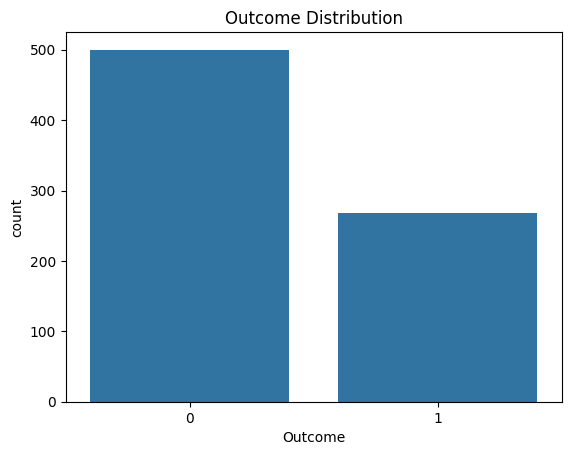

In [4]:
print('Outcome distribution:')
print(df[TARGET].value_counts(normalize=True).mul(100).round(2))
sns.countplot(x=TARGET, data=df)
plt.title('Outcome Distribution')
plt.show()

## 2) Missing/Invalid Value Handling

Replace invalid zeros with NaN for clinical columns, then apply outcome-aware median imputation.

In [6]:
df_proc = df.copy()
df_proc[FEATURES_WITH_INVALID_ZEROS] = df_proc[FEATURES_WITH_INVALID_ZEROS].replace(0, np.nan)
print('Missing before fill:', df_proc.isna().sum())

for col in FEATURES_WITH_INVALID_ZEROS:
    med0 = df_proc.loc[(df_proc[TARGET] == 0) & (df_proc[col].notna()), col].median()
    med1 = df_proc.loc[(df_proc[TARGET] == 1) & (df_proc[col].notna()), col].median()
    df_proc.loc[(df_proc[TARGET] == 0) & (df_proc[col].isna()), col] = med0
    df_proc.loc[(df_proc[TARGET] == 1) & (df_proc[col].isna()), col] = med1

print('Missing after fill:', df_proc.isna().sum())

Missing before fill: Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing after fill: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 3) Outlier handling

Cap Insulin outliers using IQR upper bound.

In [7]:
q1, q3 = df_proc['Insulin'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
df_proc['Insulin'] = np.where(df_proc['Insulin'] > upper, upper, df_proc['Insulin'])
upper

270.0

## 4) EDA Visualizations

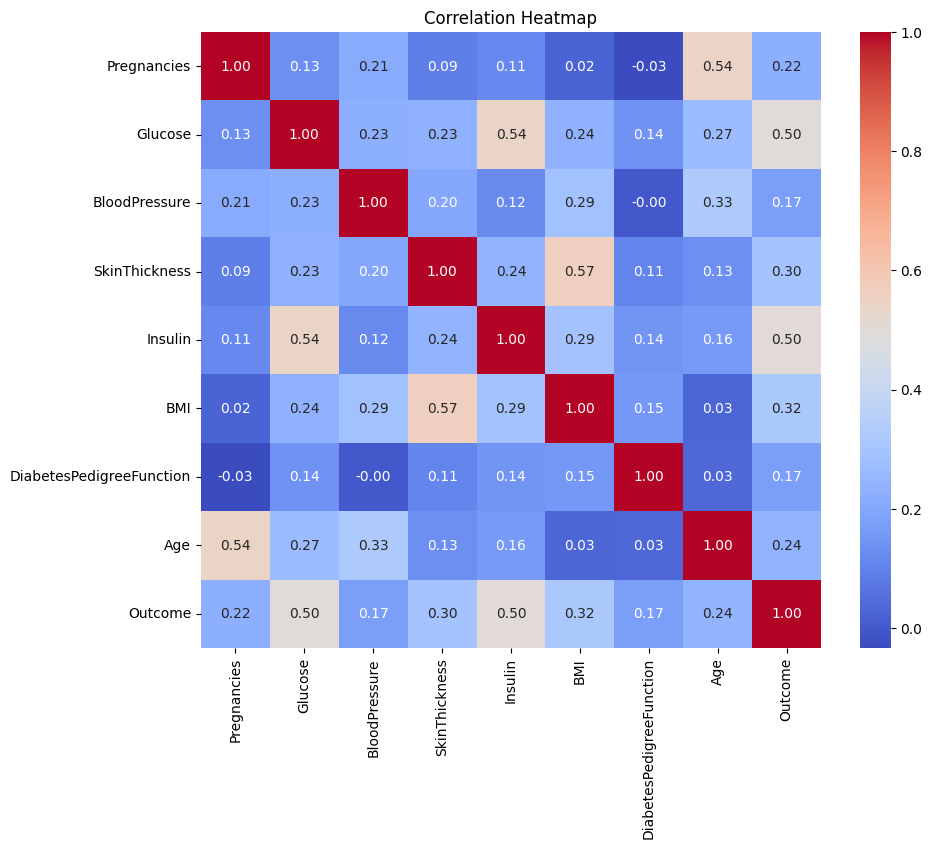

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_proc.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

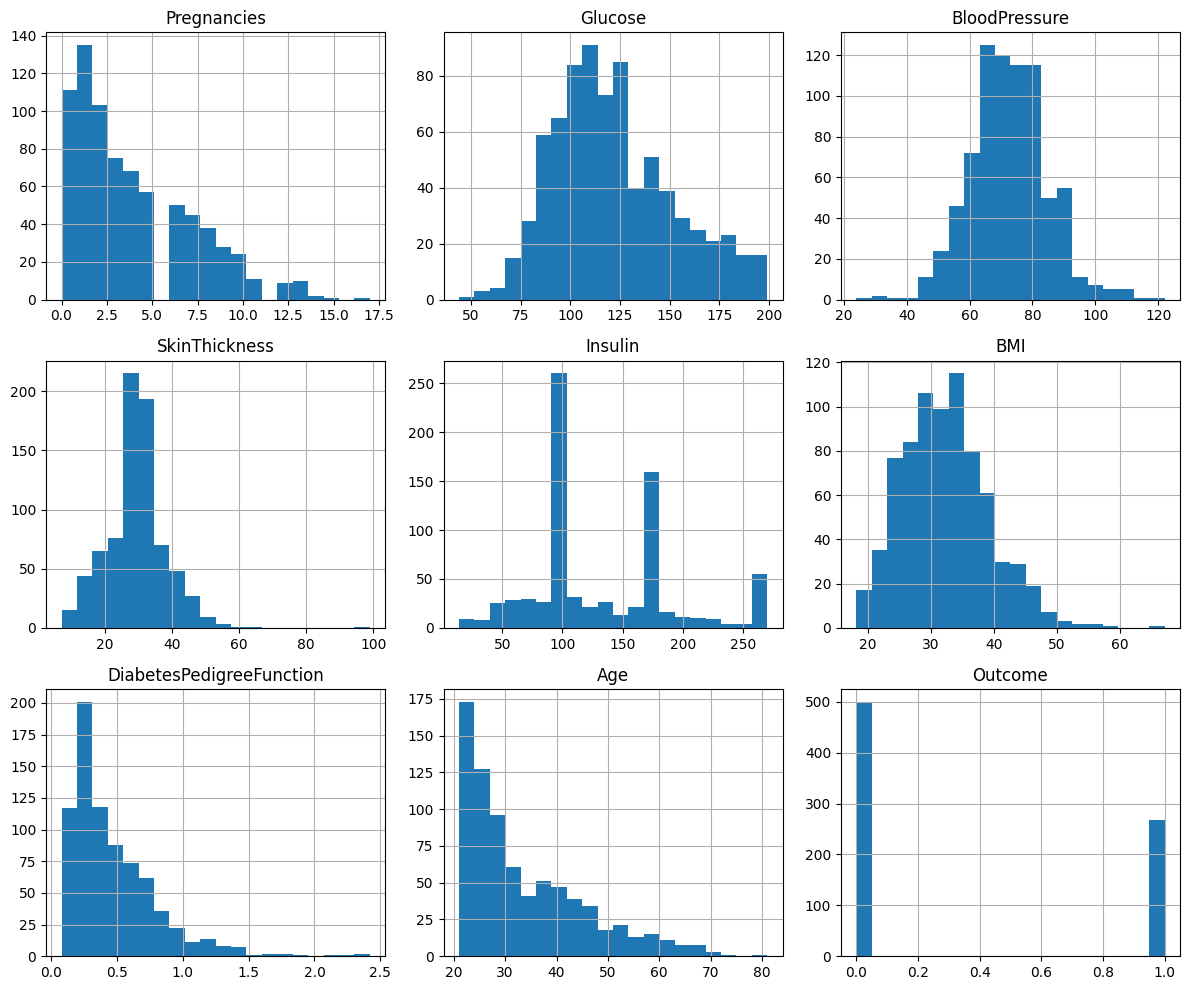

In [9]:
df_proc.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

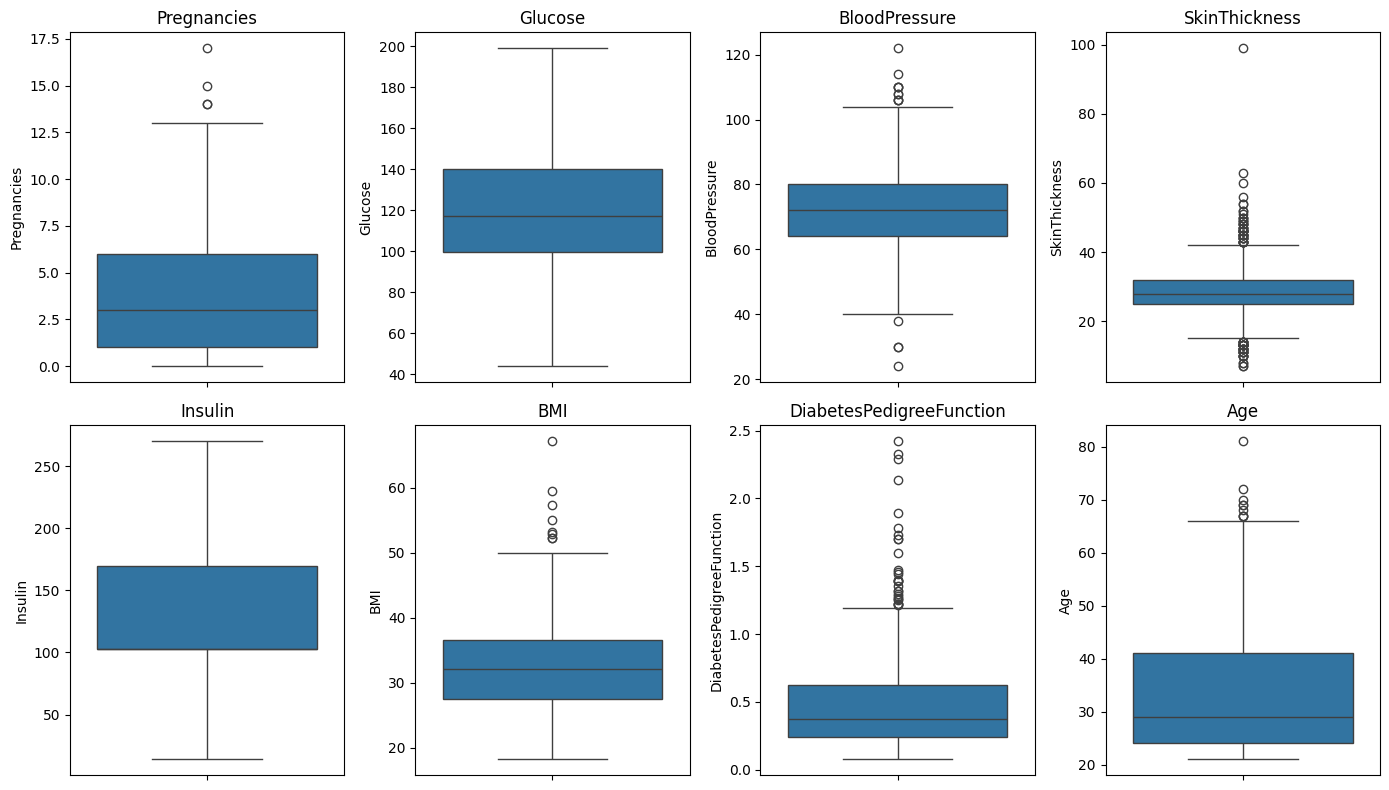

In [10]:
plt.figure(figsize=(14, 8))
for i, c in enumerate(df_proc.columns[:-1], 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_proc[c])
    plt.title(c)
plt.tight_layout()
plt.show()

## 5) Train/Test Split + Robust Scaling

In [11]:
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_full = scaler.transform(X)

## 6) Train & Tune 3 Models

In [12]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

"""
    LOGISTIC -> BASELINE (Linear)
    RF -> TUNED (Bagging)
    XGB -> HYPERTUNED (Boosting)
"""
grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=42),
        {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [300, 500], 'max_depth': [8, None], 'max_features': [3, 5, 7], 'min_samples_split': [2, 5]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'learning_rate': [0.01, 0.1], 'n_estimators': [100, 300], 'max_depth': [3, 5], 'subsample': [0.9, 1.0]}
    ),
}

def eval_metrics(model, Xte, yte):
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {
        'accuracy': accuracy_score(yte, pred),
        'precision': precision_score(yte, pred),
        'recall': recall_score(yte, pred),
        'f1_score': f1_score(yte, pred),
        'roc_auc': roc_auc_score(yte, prob),
    }

rows, trained = [], {}
for name, (base_model, params) in grids.items():
    gs = GridSearchCV(base_model, params, scoring='accuracy', cv=cv, n_jobs=-1)
    gs.fit(X_train_scaled, y_train)
    best = gs.best_estimator_
    trained[name] = best

    cv_acc = cross_val_score(best, X_scaled_full, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    m = eval_metrics(best, X_test_scaled, y_test)
    m.update({'model': name, 'cv_accuracy': cv_acc, 'best_params': gs.best_params_})
    rows.append(m)

comparison = pd.DataFrame(rows).sort_values(['roc_auc', 'f1_score'], ascending=False)
comparison

,accuracy,precision,recall,f1_score,roc_auc,model,cv_accuracy,best_params
2,0.883117,0.860000,0.796296,0.826923,0.959259,Gradient Boosting,0.885441,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est..."
1,0.876623,0.830189,0.814815,0.822430,0.952593,Random Forest,0.881545,"{'max_depth': None, 'max_features': 5, 'min_sa..."
0,0.753247,0.660000,0.611111,0.634615,0.837963,Logistic Regression,0.800735,"{'C': 0.1, 'solver': 'lbfgs'}"


## 7) Select Best Model and Save `best_model.pkl`

In [13]:
best_name = comparison.iloc[0]['model']
best_model = trained[best_name]
joblib.dump({'model': best_model, 'scaler': scaler}, '../ml_model/best_model.pkl')
print('Best model:', best_name)
print('Saved to ../ml_model/best_model.pkl')

Best model: Gradient Boosting
Saved to ../ml_model/best_model.pkl
